#Imports


In [99]:
# Visualisation Imports
import matplotlib.pyplot as plt        # For plotting and visualisations
import seaborn as sns                  # For statistical visualisations


# Preprocessing Imports
import pandas as pd                   #For data manipulation & analysis
import numpy as np                    #For numerical operations
from sklearn import preprocessing # Import the preprocessing module from scikit-learn for data transformation utilities
from collections import Counter # Import Counter to count occurrences of labels/classes in the dataset
from sklearn.preprocessing import StandardScaler # Import StandardScaler to normalize the feature values (mean = 0, std = 1)
from imblearn.over_sampling import SMOTE   #to balance our data using smote
from sklearn.model_selection import train_test_split # to split the data into test and train sets
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)  #For performance metrics
from sklearn.preprocessing import LabelEncoder  # For label encoding


In [100]:
!pip install imbalanced-learn

In [101]:
# Modelling Imports
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier model from scikit-learn
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for hyperparameter tuning using cross-validation
import shap                            # For SHAP value analysis

In [102]:
!pip install lime

In [103]:
from lime import lime_tabular

In [104]:
from lime.lime_tabular import LimeTabularExplainer


In [105]:
!pip install xgboost

In [106]:
from xgboost import XGBClassifier

#Dataset

In [107]:
# Load the dataset into a DataFrame
df = pd.read_csv("german_credit_data.csv")

In [108]:
# Display the first 5 rows of the dataset to understand its structure
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,num_existing_credits,job,num_liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [109]:
# Check the shape of the dataset
df.shape

(1000, 21)

In [110]:
#Check the data types
print(df.dtypes)

checking_account_status          str
duration_months                int64
credit_history                   str
purpose                          str
credit_amount                  int64
savings_account_bonds            str
present_employment_since         str
installment_rate_pct_income    int64
personal_status_sex              str
other_debtors_guarantors         str
present_residence_since        int64
property                         str
age_years                      int64
other_installment_plans          str
housing                          str
num_existing_credits           int64
job                              str
num_liable_people              int64
telephone                        str
foreign_worker                   str
credit_risk                    int64
dtype: object


#Visualisations


In [111]:
# Define the mapping for credit_risk
credit_risk_map = {
    1: 'Good Credit Risk',
    2: 'Bad Credit Risk'
}

# Apply the mapping to the 'credit_risk' column
df['credit_risk'] = df['credit_risk'].map(credit_risk_map)

In [112]:
# Display the first 5 rows of the dataset
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,num_existing_credits,job,num_liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,Good Credit Risk
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,Bad Credit Risk
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,Good Credit Risk
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,Good Credit Risk
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,Bad Credit Risk


Loan Status Distribution

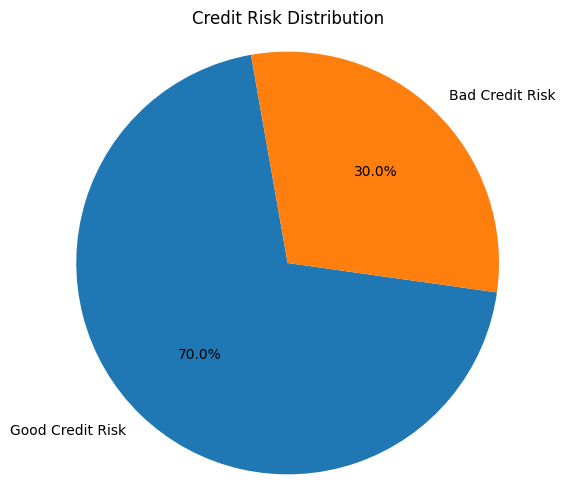

In [113]:
# Count the values in the 'credit_risk' column
credit_risk_counts = df['credit_risk'].value_counts()

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(credit_risk_counts, labels=credit_risk_counts.index, autopct='%1.1f%%', startangle=100)
plt.title('Credit Risk Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#autopct='%1.1f%%' shows percentages on the chart.
#startangle=140 rotates the start of the pie chart for aesthetics.

Histograms

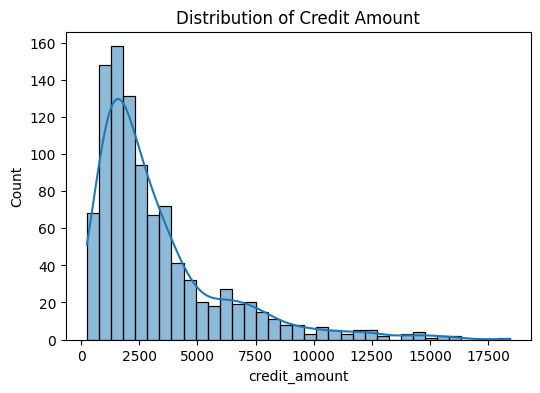

In [114]:
# Histogram for Credit Amount
plt.figure(figsize=(6, 4))
sns.histplot(df['credit_amount'], kde=True)
plt.title('Distribution of Credit Amount')
plt.show()

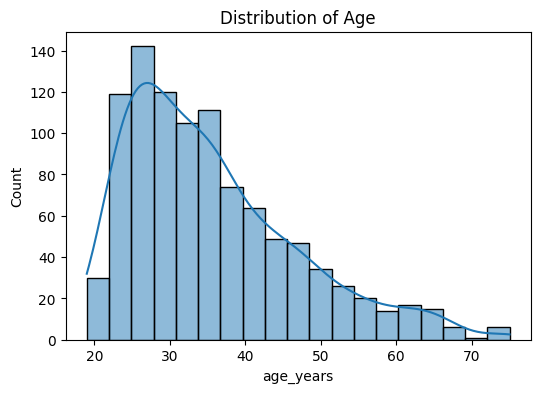

In [115]:
# Histogram for Age
plt.figure(figsize=(6, 4))
sns.histplot(df['age_years'], kde=True)
plt.title('Distribution of Age')
plt.show()

Grouped Bar Charts

In [116]:
# Split personal_status_sex into separate gender and marital_status columns
gender_map = {
    'A91': 'Male',
    'A92': 'Female',
    'A93': 'Male',
    'A94': 'Male',
    'A95': 'Female'
}

marital_status_map = {
    'A91': 'Divorced/Separated',
    'A92': 'Divorced/Separated/Married',
    'A93': 'Single',
    'A94': 'Married/Widowed',
    'A95': 'Single'
}

df['gender'] = df['personal_status_sex'].map(gender_map)
df['marital_status'] = df['personal_status_sex'].map(marital_status_map)

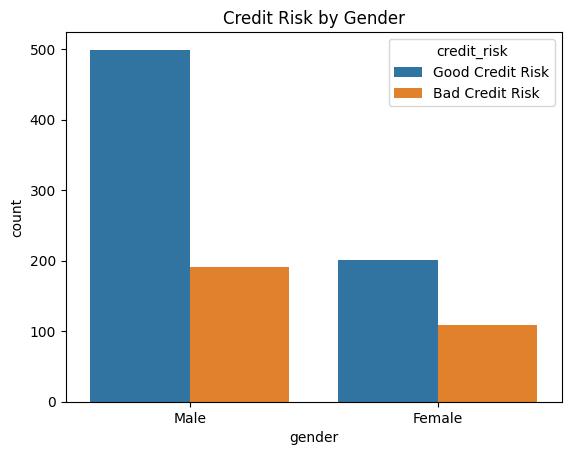

In [117]:
# Credit Risk by Gender
sns.countplot(data=df, x='gender', hue='credit_risk')
plt.title('Credit Risk by Gender')
plt.show()

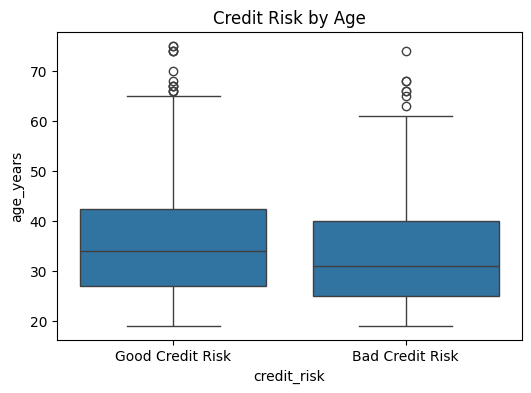

In [118]:
# Credit Risk by Age
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='credit_risk', y='age_years')
plt.title('Credit Risk by Age')
plt.show()

In [119]:
# Map credit_history codes to readable labels
credit_history_map = {
    'A30': 'No Credits/All Paid',
    'A31': 'All Credits Paid',
    'A32': 'Existing Credits Paid',
    'A33': 'Delay in Past',
    'A34': 'Critical Account'
}

df['credit_history'] = df['credit_history'].map(credit_history_map)

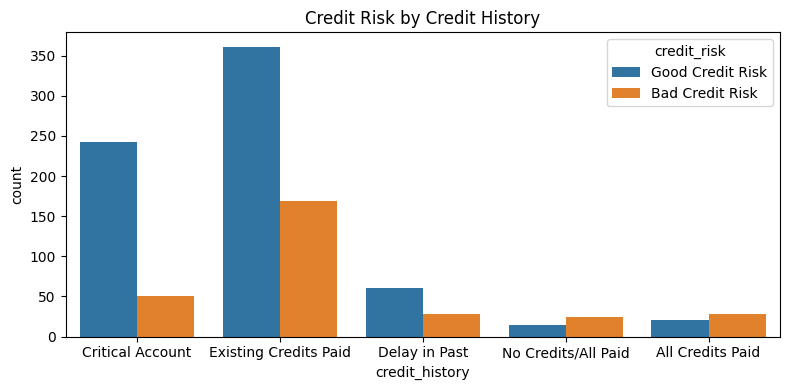

In [120]:
# Credit Risk by Credit History
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='credit_history', hue='credit_risk')
plt.title('Credit Risk by Credit History')
plt.tight_layout()
plt.show()

# Correlation Analysis

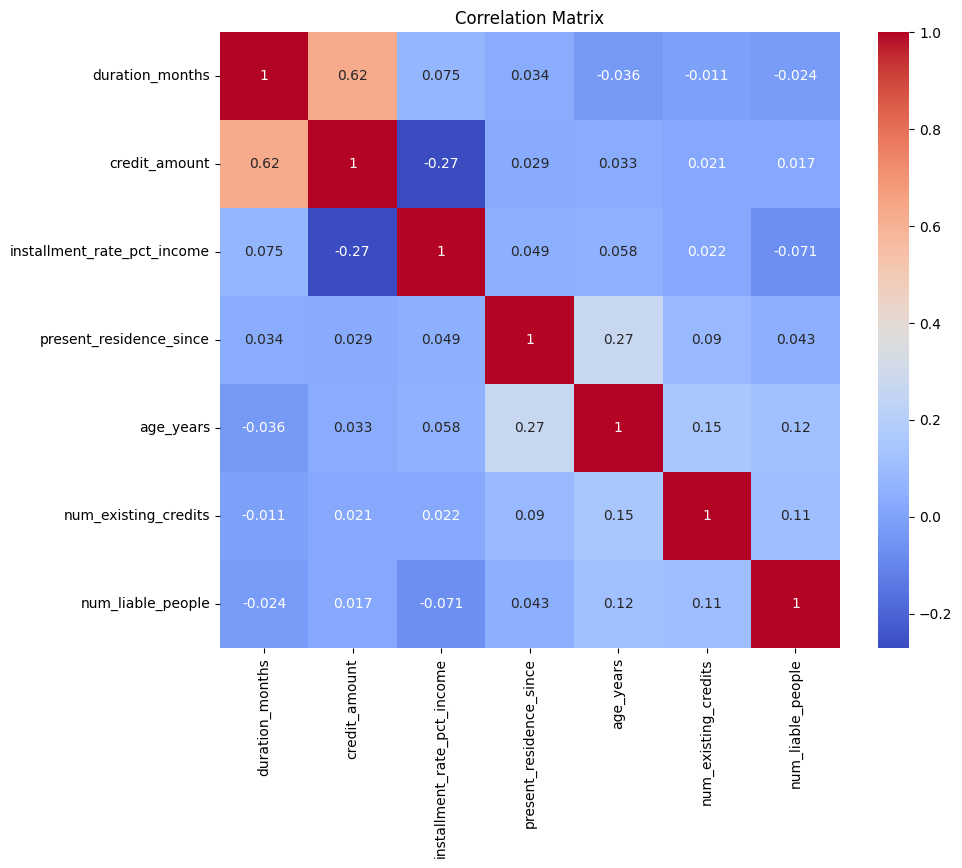

In [121]:
# Create the correlation matrix for all numeric features in the df
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap using seaborn to visualise the correlation matrix
# 'annot=True' displays the correlation coefficients inside the squares
# 'cmap="coolwarm"' sets the color scheme for better visual distinction of positive and negative correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# Add a title to the heatmap
plt.title("Correlation Matrix")

# Display the heatmap plot
plt.show()

#Descriptive Statistics

In [122]:
# Display summary statistics for numeric columns
df.describe()

,duration_months,credit_amount,installment_rate_pct_income,present_residence_since,age_years,num_existing_credits,num_liable_people
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [123]:
# Basic statistics for categorical columns
df.describe(include=['object'])

C:\Users\misha\AppData\Local\Temp\ipykernel_67312\2132535628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,checking_account_status,credit_history,purpose,savings_account_bonds,present_employment_since,personal_status_sex,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker,credit_risk,gender,marital_status
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2,2,2,4
top,A14,Existing Credits Paid,A43,A61,A73,A93,A101,A123,A143,A152,A173,A191,A201,Good Credit Risk,Male,Single
freq,394,530,280,603,339,548,907,332,814,713,630,596,963,700,690,548


# Data Preprocessing

In [124]:
df = pd.read_csv("german_credit_data.csv")

In [125]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,num_existing_credits,job,num_liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Dropping Noisy Attributes

In [126]:
# Map credit_risk target: 1 (Good) -> 1, 2 (Bad) -> 0
df['credit_risk'] = df['credit_risk'].map({1: 1, 2: 0})

In [127]:
# Display the first 5 rows of the dataset
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,num_existing_credits,job,num_liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


Handling Missing Values

In [128]:
# Check for missing values in the dataset
df.isnull().sum()

checking_account_status        0
duration_months                0
credit_history                 0
purpose                        0
credit_amount                  0
savings_account_bonds          0
present_employment_since       0
installment_rate_pct_income    0
personal_status_sex            0
other_debtors_guarantors       0
present_residence_since        0
property                       0
age_years                      0
other_installment_plans        0
housing                        0
num_existing_credits           0
job                            0
num_liable_people              0
telephone                      0
foreign_worker                 0
credit_risk                    0
dtype: int64

Label Encoding

In [129]:
# Encode categorical variables using Label Encoding

# Initiate the encoder
le = LabelEncoder()

# Apply label encoding to the 'checking_account_status' column
df['checking_account_status'] = le.fit_transform(df['checking_account_status'])

# Apply label encoding to the 'credit_history' column
df['credit_history'] = le.fit_transform(df['credit_history'])

# Apply label encoding to the 'purpose' column
df['purpose'] = le.fit_transform(df['purpose'])

# Apply label encoding to the 'savings_account_bonds' column
df['savings_account_bonds'] = le.fit_transform(df['savings_account_bonds'])

# Apply label encoding to the 'present_employment_since' column
df['present_employment_since'] = le.fit_transform(df['present_employment_since'])

# Apply label encoding to the 'personal_status_sex' column
df['personal_status_sex'] = le.fit_transform(df['personal_status_sex'])

# Apply label encoding to the 'other_debtors_guarantors' column
df['other_debtors_guarantors'] = le.fit_transform(df['other_debtors_guarantors'])

# Apply label encoding to the 'property' column
df['property'] = le.fit_transform(df['property'])

# Apply label encoding to the 'other_installment_plans' column
df['other_installment_plans'] = le.fit_transform(df['other_installment_plans'])

# Apply label encoding to the 'housing' column
df['housing'] = le.fit_transform(df['housing'])

# Apply label encoding to the 'job' column
df['job'] = le.fit_transform(df['job'])

# Apply label encoding to the 'telephone' column
df['telephone'] = le.fit_transform(df['telephone'])

# Apply label encoding to the 'foreign_worker' column
df['foreign_worker'] = le.fit_transform(df['foreign_worker'])

In [130]:
# Display the first 5 rows of the dataset
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,num_existing_credits,job,num_liable_people,telephone,foreign_worker,credit_risk
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,0
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,0


Balancing the classes and splitting the train and test sets

In [131]:
credit_risk_count = df['credit_risk'].value_counts()
print(credit_risk_count)

credit_risk
1    700
0    300
Name: count, dtype: int64


In [132]:
X = df.iloc[:, :-1].values    # predictor attributes
y = df.iloc[:,-1].values     # target attribute

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [134]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 559, np.int64(1): 559})

#Classification on the Loan_Status feature

# **1. Random Forest Model**

Feature Importance

In [135]:
# Fitting the RF model to the df before balancing
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

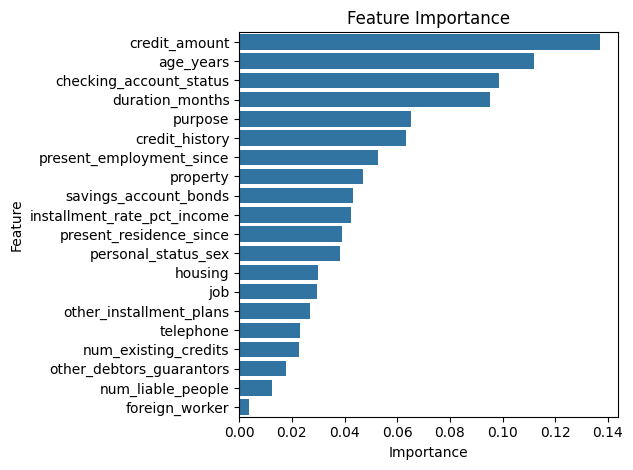

In [136]:
importances = model.feature_importances_

# Use original column names
feature_names = df.drop('credit_risk', axis=1).columns

# Create and sort DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# **Random Forest with all features**



In [137]:
# Fitting the RF Model to the balanced data
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [138]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[460  99]
 [120 439]]
Accuracy: 0.8041144901610018
Precision: 0.8159851301115242
Recall: 0.7853309481216458
F1 Score: 0.8003646308113036
AUC Score: 0.8896300895094422

Classification Report:
               precision    recall  f1-score   support

          No       0.79      0.82      0.81       559
         Yes       0.82      0.79      0.80       559

    accuracy                           0.80      1118
   macro avg       0.80      0.80      0.80      1118
weighted avg       0.80      0.80      0.80      1118



# **Random Forest after feature selection**

In [140]:
# Before running this cell, drop noisy attributes, handle missing values, encode categorical features
# Drop low-importance features and retrain the model to compare performance
low_importance_features = ['foreign_worker', 'telephone', 'num_liable_people']
df_reduced = df.drop(columns=low_importance_features)

In [141]:
df_reduced.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,num_existing_credits,job,credit_risk
0,0,6,4,4,1169,4,4,4,2,0,4,0,67,2,1,2,2,1
1,1,48,2,4,5951,0,2,2,1,0,2,0,22,2,1,1,2,0
2,3,12,4,7,2096,0,3,2,2,0,3,0,49,2,1,1,1,1
3,0,42,2,3,7882,0,3,2,2,2,4,1,45,2,2,1,2,1
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,0


In [142]:
loan_status_count = df_reduced['credit_risk'].value_counts()
print(loan_status_count)

credit_risk
1    700
0    300
Name: count, dtype: int64


In [143]:
X = df_reduced.iloc[:, :-1].values    # predictor attributes
y = df_reduced.iloc[:,-1].values     # target attribute

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [145]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 559, np.int64(1): 559})

In [146]:
# Fitting the RF Model to the balanced and scaled data after feature selection
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [147]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[462  97]
 [119 440]]
Accuracy: 0.8067978533094812
Precision: 0.819366852886406
Recall: 0.7871198568872988
F1 Score: 0.8029197080291971
AUC Score: 0.8860474716862786

Classification Report:
               precision    recall  f1-score   support

          No       0.80      0.83      0.81       559
         Yes       0.82      0.79      0.80       559

    accuracy                           0.81      1118
   macro avg       0.81      0.81      0.81      1118
weighted avg       0.81      0.81      0.81      1118



# **Hyperparameter Tuning for RF Model**

In [148]:
# Defining the parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20, None],  # Varying depth levels for different levels of complexity
    'n_estimators': [50, 100, 150],     # Number of trees in the forest
    'min_samples_split': [2, 10, 20],    # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],    # Max number of features considered for splitting
    'bootstrap': [True, False]           # Whether bootstrap samples are used when building trees
}

# Creating the model
rf = RandomForestClassifier(random_state=42)

# Set up grid search for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,            # The base model: RandomForestClassifier
    param_grid=param_grid,   # Dictionary of hyperparameter(s) to test
    cv=5,                    # 5-fold cross-validation to evaluate each setting
    scoring='f1',            # Use f1 score to evaluate model performance
    n_jobs=-1,               # Use all available CPU cores for faster computation
    verbose=1                # Show progress of the grid search in the console
)

# Fitting the grid search to the data
grid_search.fit(X_train_sm, y_train_sm)

# Getting the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score: 0.8177780172964212


In [149]:
# Use the best estimator found by GridSearchCV

final_model = grid_search.best_estimator_

# Fit the model to the balanced and scaled training data
final_model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [150]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[457 102]
 [107 452]]
Accuracy: 0.8130590339892666
Precision: 0.8158844765342961
Recall: 0.8085867620751341
F1 Score: 0.8122192273135669
AUC Score: 0.8891788620748142

Classification Report:
               precision    recall  f1-score   support

          No       0.81      0.82      0.81       559
         Yes       0.82      0.81      0.81       559

    accuracy                           0.81      1118
   macro avg       0.81      0.81      0.81      1118
weighted avg       0.81      0.81      0.81      1118



# **2. XGBoost Model**

In [151]:
#Creating and fitting the model
xgb_model = XGBClassifier(
    eval_metric='logloss',   # Recommended for binary classification
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [152]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [153]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions (label predictions)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 â€” 'Yes')
y_proba_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_xgb = pd.Series(y_pred_cv_xgb).map(label_map)

# Confusion matrix
cm_xgb = confusion_matrix(y_true_named, y_pred_named_xgb)
print("Confusion Matrix:\n", cm_xgb)

# Accuracy
acc_xgb = accuracy_score(y_true_named, y_pred_named_xgb)
print("Accuracy:", acc_xgb)

# Precision
precision_xgb = precision_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Precision:", precision_xgb)

# Recall
recall_xgb = recall_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Recall:", recall_xgb)

# F1 Score
f1_xgb = f1_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("F1 Score:", f1_xgb)

# AUC Score
auc_xgb = roc_auc_score(y_train_sm, y_proba_cv_xgb)
print("AUC Score:", auc_xgb)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_xgb))

Confusion Matrix:
 [[451 108]
 [121 438]]
Accuracy: 0.7951699463327371
Precision: 0.8021978021978022
Recall: 0.7835420393559929
F1 Score: 0.7927601809954751
AUC Score: 0.8777301659940926

Classification Report:
               precision    recall  f1-score   support

          No       0.79      0.81      0.80       559
         Yes       0.80      0.78      0.79       559

    accuracy                           0.80      1118
   macro avg       0.80      0.80      0.80      1118
weighted avg       0.80      0.80      0.80      1118



# **XGBOOST Hyperparameter Tuning**


In [154]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [155]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [156]:
grid_search.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [157]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score: 0.819333505885685


In [158]:
best_xgb_model = grid_search.best_estimator_

In [159]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
print("Accuracy:", accuracy_score(y_true_named, y_pred_named))

# Precision
print("Precision:", precision_score(y_true_named, y_pred_named, pos_label='Yes'))

# Recall
print("Recall:", recall_score(y_true_named, y_pred_named, pos_label='Yes'))

# F1 Score
print("F1 Score:", f1_score(y_true_named, y_pred_named, pos_label='Yes'))

# AUC Score
print("AUC Score:", roc_auc_score(y_train_sm, y_proba_cv))

# Full report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[457 102]
 [112 447]]
Accuracy: 0.8085867620751341
Precision: 0.8142076502732241
Recall: 0.7996422182468694
F1 Score: 0.8068592057761733
AUC Score: 0.8891196584752353

Classification Report:
               precision    recall  f1-score   support

          No       0.80      0.82      0.81       559
         Yes       0.81      0.80      0.81       559

    accuracy                           0.81      1118
   macro avg       0.81      0.81      0.81      1118
weighted avg       0.81      0.81      0.81      1118



# **3. Ensemble Model**

# **Stacking Ensemble Model**

In [160]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [161]:
# Base learners
estimators = [
    ('rf', final_model),  # already tuned
    ('xgb', best_xgb_model)  # already tuned
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression()

# Stacking classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# Fit on full training data so it can be used for test set predictions
stacking_model.fit(X_train_sm, y_train_sm)
print('Stacking model fitted.')

Stacking model fitted.


In [162]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Cross-validated predictions — single pass: get probabilities then derive labels
y_proba_cv_stack = cross_val_predict(stacking_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]
y_pred_cv_stack = (y_proba_cv_stack >= 0.5).astype(int)

# Map labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_stack = pd.Series(y_pred_cv_stack).map(label_map)

# Metrics
cm_stack = confusion_matrix(y_true_named, y_pred_named_stack)
print("Confusion Matrix:\n", cm_stack)

acc_stack = accuracy_score(y_true_named, y_pred_named_stack)
print("Accuracy:", acc_stack)

precision_stack = precision_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Precision:", precision_stack)

recall_stack = recall_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Recall:", recall_stack)

f1_stack = f1_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("F1 Score:", f1_stack)

auc_stack = roc_auc_score(y_train_sm, y_proba_cv_stack)
print("AUC Score:", auc_stack)

print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_stack))

Confusion Matrix:
 [[457 102]
 [ 99 460]]
Accuracy: 0.8202146690518783
Precision: 0.8185053380782918
Recall: 0.8228980322003577
F1 Score: 0.8206958073148974
AUC Score: 0.8867323133246501

Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.82      0.82       559
         Yes       0.82      0.82      0.82       559

    accuracy                           0.82      1118
   macro avg       0.82      0.82      0.82      1118
weighted avg       0.82      0.82      0.82      1118



# **Voting Ensemble** **Model**

In [163]:
from sklearn.ensemble import VotingClassifier

# Build the voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('rf', final_model), ('xgb', best_xgb_model)],
    voting='soft'
)

# Fit the ensemble model
ensemble_model.fit(X_train_sm, y_train_sm)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [164]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Generate cross-validated predictions (label predictions)
y_pred_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 â€” 'Yes')
y_proba_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_ens = pd.Series(y_pred_cv_ens).map(label_map)

# Confusion matrix
cm_ens = confusion_matrix(y_true_named, y_pred_named_ens)
print("Confusion Matrix:\n", cm_ens)

# Accuracy
acc_ens = accuracy_score(y_true_named, y_pred_named_ens)
print("Accuracy:", acc_ens)

# Precision
precision_ens = precision_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Precision:", precision_ens)

# Recall
recall_ens = recall_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Recall:", recall_ens)

# F1 Score
f1_ens = f1_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("F1 Score:", f1_ens)

# AUC Score
auc_ens = roc_auc_score(y_train_sm, y_proba_cv_ens)
print("AUC Score:", auc_ens)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_ens))

Confusion Matrix:
 [[460  99]
 [102 457]]
Accuracy: 0.8202146690518783
Precision: 0.8219424460431655
Recall: 0.817531305903399
F1 Score: 0.8197309417040358
AUC Score: 0.8935135256223579

Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.82      0.82       559
         Yes       0.82      0.82      0.82       559

    accuracy                           0.82      1118
   macro avg       0.82      0.82      0.82      1118
weighted avg       0.82      0.82      0.82      1118



## Statistical Rigor Analysis

In [165]:
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [166]:
def compute_variance_analysis(models, X_train_sm, y_train_sm):
    # Initialize CV strategy
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Initialize results storage
    results = []
    f1_scores_dict = {}
    
    # Compute metrics for each model
    for model_name, model in models:
        # Compute per-fold scores for each metric
        accuracy_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='accuracy', n_jobs=1)
        precision_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='precision', n_jobs=1)
        recall_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='recall', n_jobs=1)
        f1_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=1)
        auc_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='roc_auc', n_jobs=1)
        
        # Store F1 scores for reuse in significance testing
        f1_scores_dict[model_name] = f1_scores
        
        # Format results as mean Â± std with 2 decimal places
        results.append({
            'Model': model_name,
            'Accuracy': f"{accuracy_scores.mean():.2f} Â± {accuracy_scores.std():.2f}",
            'Precision': f"{precision_scores.mean():.2f} Â± {precision_scores.std():.2f}",
            'Recall': f"{recall_scores.mean():.2f} Â± {recall_scores.std():.2f}",
            'F1': f"{f1_scores.mean():.2f} Â± {f1_scores.std():.2f}",
            'AUC': f"{auc_scores.mean():.2f} Â± {auc_scores.std():.2f}"
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, f1_scores_dict

In [167]:
def compute_significance_testing(models, X_train_sm, y_train_sm, f1_scores_dict=None):
    from itertools import combinations
    
    # If f1_scores_dict not provided, compute per-fold F1 scores
    if f1_scores_dict is None:
        # Initialize CV strategy (same as variance analysis)
        cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Collect per-fold F1 scores for all models
        f1_scores_dict = {}
        for model_name, model in models:
            f1_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=1)
            f1_scores_dict[model_name] = f1_scores
    
    # Extract model names
    model_names = [name for name, _ in models]
    
    # Generate all pairwise combinations
    model_pairs = list(combinations(model_names, 2))
    
    # Initialize results matrix as a dictionary
    results = {}
    for name in model_names:
        results[name] = {}
    
    # Perform pairwise comparisons
    for model_A, model_B in model_pairs:
        # Get per-fold F1 scores
        scores_A = f1_scores_dict[model_A]
        scores_B = f1_scores_dict[model_B]
        
        # Perform paired t-test (primary)
        t_statistic, p_value_ttest = ttest_rel(scores_A, scores_B)
        
        # Perform Wilcoxon signed-rank test (supplementary)
        w_statistic, p_value_wilcoxon = wilcoxon(scores_A, scores_B)
        
        # Determine significance (using t-test as primary)
        is_significant = (p_value_ttest < 0.05)
        
        # Format result with both p-values
        if is_significant:
            result_string = f"t: p={p_value_ttest:.4f}*, W: p={p_value_wilcoxon:.4f}"
        else:
            result_string = f"t: p={p_value_ttest:.4f}, W: p={p_value_wilcoxon:.4f}"
        
        # Add to results matrix (symmetric)
        results[model_A][model_B] = result_string
        results[model_B][model_A] = result_string
    
    # Fill diagonal with dashes
    for name in model_names:
        results[name][name] = "â€”"
    
    # Create DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df[model_names]  # Ensure column order matches row order
    
    return results_df

In [168]:
# Create list of models for analysis
models = [
    ('Tuned RF', final_model),
    ('Tuned XGBoost', best_xgb_model),
    ('Stacking', stacking_model),
    ('Voting', ensemble_model)
]

# Execute variance analysis
variance_results_df, f1_scores_dict = compute_variance_analysis(models, X_train_sm, y_train_sm)

# Display results
print("\n=== Variance Analysis Results ===")
print(variance_results_df.to_string(index=False))


=== Variance Analysis Results ===
        Model     Accuracy    Precision       Recall           F1          AUC
     Tuned RF 0.81 Â± 0.03 0.84 Â± 0.06 0.79 Â± 0.05 0.81 Â± 0.03 0.90 Â± 0.02
Tuned XGBoost 0.81 Â± 0.03 0.82 Â± 0.05 0.79 Â± 0.05 0.80 Â± 0.03 0.89 Â± 0.02
     Stacking 0.81 Â± 0.03 0.83 Â± 0.05 0.80 Â± 0.05 0.81 Â± 0.03 0.90 Â± 0.02
       Voting 0.82 Â± 0.03 0.83 Â± 0.05 0.80 Â± 0.06 0.81 Â± 0.03 0.90 Â± 0.02


### Variance Analysis Interpretation

In [169]:
# Execute significance testing using the same models list and F1 scores from variance analysis
significance_results_df = compute_significance_testing(models, X_train_sm, y_train_sm, f1_scores_dict)

# Display results
print("\n=== Statistical Significance Testing Results ===")
print(significance_results_df)


=== Statistical Significance Testing Results ===
                               Tuned RF             Tuned XGBoost  \
Tuned RF                            â€”  t: p=0.2667, W: p=0.6250   
Tuned XGBoost  t: p=0.2667, W: p=0.6250                       â€”   
Stacking       t: p=0.6878, W: p=0.6250  t: p=0.2805, W: p=0.4375   
Voting         t: p=0.2735, W: p=0.3125  t: p=0.1296, W: p=0.3125   

                               Stacking                    Voting  
Tuned RF       t: p=0.6878, W: p=0.6250  t: p=0.2735, W: p=0.3125  
Tuned XGBoost  t: p=0.2805, W: p=0.4375  t: p=0.1296, W: p=0.3125  
Stacking                            â€”  t: p=0.7429, W: p=0.6250  
Voting         t: p=0.7429, W: p=0.6250                       â€”  


### Statistical Significance Testing Interpretation

In [170]:
def compute_cv_metrics(model, X, y, cv_strategy):
    # Compute per-fold scores for each metric
    accuracy_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy')
    precision_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='precision')
    recall_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='recall')
    f1_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='f1')
    auc_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='roc_auc')
    
    # Return dictionary with formatted strings and raw F1 mean
    return {
        'accuracy': f"{accuracy_scores.mean():.2f} Â± {accuracy_scores.std():.2f}",
        'precision': f"{precision_scores.mean():.2f} Â± {precision_scores.std():.2f}",
        'recall': f"{recall_scores.mean():.2f} Â± {recall_scores.std():.2f}",
        'f1': f"{f1_scores.mean():.2f} Â± {f1_scores.std():.2f}",
        'auc': f"{auc_scores.mean():.2f} Â± {auc_scores.std():.2f}",
        'f1_mean': f1_scores.mean()  # Raw mean for delta calculation
    }

In [171]:
def compute_ablation_study(X_train, y_train, X_train_sm, y_train_sm, X_train_sm_full, y_train_sm_full, final_model):
    from sklearn.ensemble import RandomForestClassifier
    
    # Initialize CV strategy (same as other modules)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Compute baseline metrics (full pipeline: SMOTE + tuned model + feature selection)
    print("Computing baseline metrics (Full Pipeline: SMOTE + Tuned RF + Feature Selection)...")
    baseline_metrics = compute_cv_metrics(final_model, X_train_sm, y_train_sm, cv_strategy)
    baseline_f1_mean = baseline_metrics['f1_mean']
    
    # Ablation 1: No SMOTE (remove SMOTE, keep tuning and feature selection)
    print("Computing No SMOTE ablation metrics...")
    no_smote_model = RandomForestClassifier(random_state=42)
    no_smote_metrics = compute_cv_metrics(no_smote_model, X_train, y_train, cv_strategy)
    no_smote_f1_mean = no_smote_metrics['f1_mean']
    delta_no_smote = no_smote_f1_mean - baseline_f1_mean
    
    # Ablation 2: No Hyperparameter Tuning (remove tuning, keep SMOTE and feature selection)
    print("Computing No Hyperparameter Tuning ablation metrics...")
    default_rf = RandomForestClassifier(random_state=42)
    no_tuning_metrics = compute_cv_metrics(default_rf, X_train_sm, y_train_sm, cv_strategy)
    no_tuning_f1_mean = no_tuning_metrics['f1_mean']
    delta_no_tuning = no_tuning_f1_mean - baseline_f1_mean
    
    # Ablation 3: No Feature Selection (remove feature selection, keep SMOTE and tuning)
    print("Computing No Feature Selection ablation metrics...")
    no_fs_metrics = compute_cv_metrics(final_model, X_train_sm_full, y_train_sm_full, cv_strategy)
    no_fs_f1_mean = no_fs_metrics['f1_mean']
    delta_no_fs = no_fs_f1_mean - baseline_f1_mean
    
    # Helper function to format delta
    def format_delta(delta):
        # delta = ablation_F1 - baseline_F1
        # Negative = removal hurt performance; Positive = removal had no detrimental effect.
        if delta > 0:
            return f"+{delta:.2f}"
        elif delta < 0:
            return f"{delta:.2f}"
        else:
            return "0.00"
    
    # Create results DataFrame
    results_data = [
        {
            'Condition': 'Baseline (Full Pipeline)',
            'Accuracy': baseline_metrics['accuracy'],
            'Precision': baseline_metrics['precision'],
            'Recall': baseline_metrics['recall'],
            'F1': baseline_metrics['f1'],
            'AUC': baseline_metrics['auc'],
            'Delta_F1': 'â€”'
        },
        {
            'Condition': 'No SMOTE',
            'Accuracy': no_smote_metrics['accuracy'],
            'Precision': no_smote_metrics['precision'],
            'Recall': no_smote_metrics['recall'],
            'F1': no_smote_metrics['f1'],
            'AUC': no_smote_metrics['auc'],
            'Delta_F1': format_delta(delta_no_smote)
        },
        {
            'Condition': 'No Hyperparameter Tuning',
            'Accuracy': no_tuning_metrics['accuracy'],
            'Precision': no_tuning_metrics['precision'],
            'Recall': no_tuning_metrics['recall'],
            'F1': no_tuning_metrics['f1'],
            'AUC': no_tuning_metrics['auc'],
            'Delta_F1': format_delta(delta_no_tuning)
        },
        {
            'Condition': 'No Feature Selection',
            'Accuracy': no_fs_metrics['accuracy'],
            'Precision': no_fs_metrics['precision'],
            'Recall': no_fs_metrics['recall'],
            'F1': no_fs_metrics['f1'],
            'AUC': no_fs_metrics['auc'],
            'Delta_F1': format_delta(delta_no_fs)
        }
    ]
    
    results_df = pd.DataFrame(results_data)
    
    return results_df

### Ablation Study

In [172]:
# Prepare data for No Feature Selection ablation
# We need SMOTE-balanced data with all 12 original features (before feature selection)
from imblearn.over_sampling import SMOTE

# Get original features (all 12 features from df, not df_reduced)
X_original = df.iloc[:, :-1].values
y_original = df.iloc[:, -1].values

# Split with same random_state to ensure consistency
from sklearn.model_selection import train_test_split
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

# Apply SMOTE to the full feature set
smote_full = SMOTE(random_state=42)
X_train_sm_full, y_train_sm_full = smote_full.fit_resample(X_train_original, y_train_original)

print(f"Original X_train shape (with feature selection): {X_train.shape}")
print(f"Full X_train_sm_full shape (all features): {X_train_sm_full.shape}")
print(f"Features removed by feature selection: {X_train_sm_full.shape[1] - X_train.shape[1]}")

Original X_train shape (with feature selection): (800, 17)
Full X_train_sm_full shape (all features): (1118, 20)
Features removed by feature selection: 3


In [173]:
# Execute ablation study
ablation_results = compute_ablation_study(
    X_train=X_train,
    y_train=y_train,
    X_train_sm=X_train_sm,
    y_train_sm=y_train_sm,
    X_train_sm_full=X_train_sm_full,
    y_train_sm_full=y_train_sm_full,
    final_model=final_model
)

# Display results
ablation_results

Computing baseline metrics (Full Pipeline: SMOTE + Tuned RF + Feature Selection)...
Computing No SMOTE ablation metrics...
Computing No Hyperparameter Tuning ablation metrics...
Computing No Feature Selection ablation metrics...


,Condition,Accuracy,Precision,Recall,F1,AUC,Delta_F1
0,Baseline (Full Pipeline),0.81 Â± 0.03,0.84 Â± 0.06,0.79 Â± 0.05,0.81 Â± 0.03,0.90 Â± 0.02,â€”
1,No SMOTE,0.76 Â± 0.02,0.79 Â± 0.02,0.89 Â± 0.02,0.84 Â± 0.02,0.78 Â± 0.05,+0.03
2,No Hyperparameter Tuning,0.80 Â± 0.04,0.83 Â± 0.05,0.77 Â± 0.06,0.80 Â± 0.04,0.90 Â± 0.02,-0.01
3,No Feature Selection,0.81 Â± 0.02,0.82 Â± 0.04,0.80 Â± 0.04,0.81 Â± 0.02,0.90 Â± 0.02,+0.00


## Evaluation Framework: Confusion Matrices, ROC Curves, and Classification Reports

In [174]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report

In [175]:
# Generate predictions and probability scores for all models
y_pred_rf = final_model.predict(X_test)
y_prob_rf = final_model.predict_proba(X_test)[:, 1]

y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]

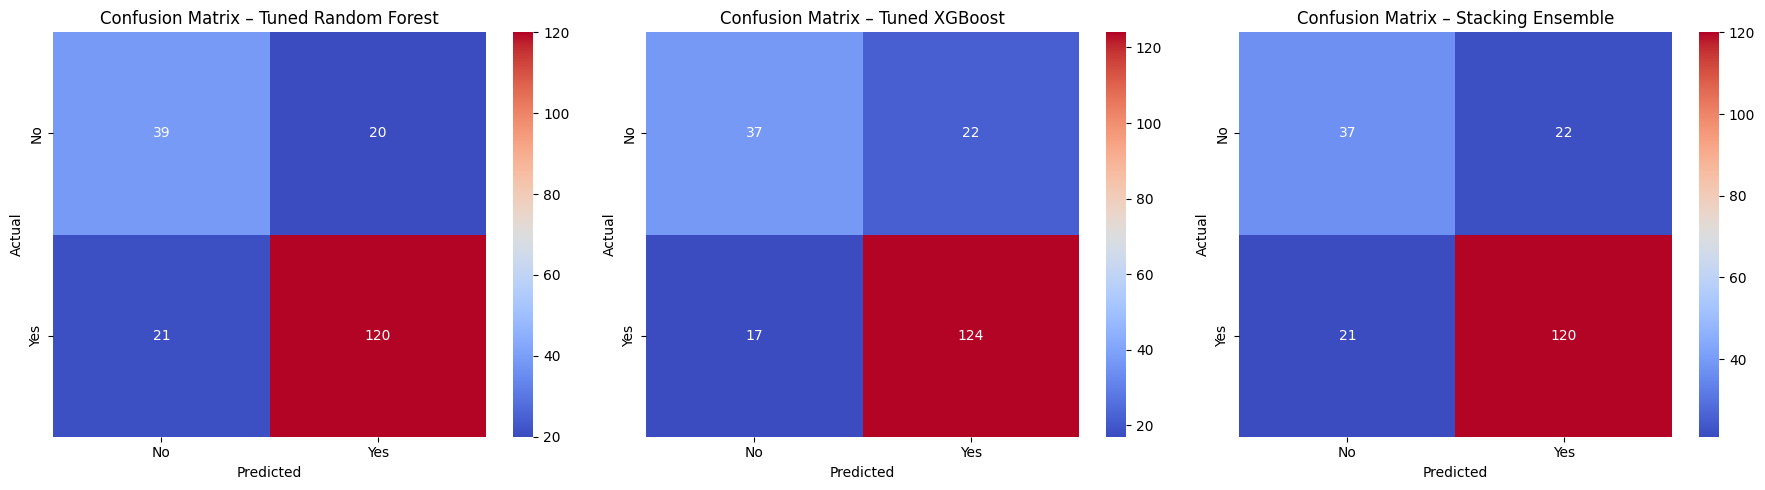

In [176]:
# Plot confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eval_models = [
    (y_pred_rf, 'Tuned Random Forest'),
    (y_pred_xgb, 'Tuned XGBoost'),
    (y_pred_stack, 'Stacking Ensemble')
]

for ax, (y_pred, name) in zip(axes, eval_models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'Confusion Matrix – {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

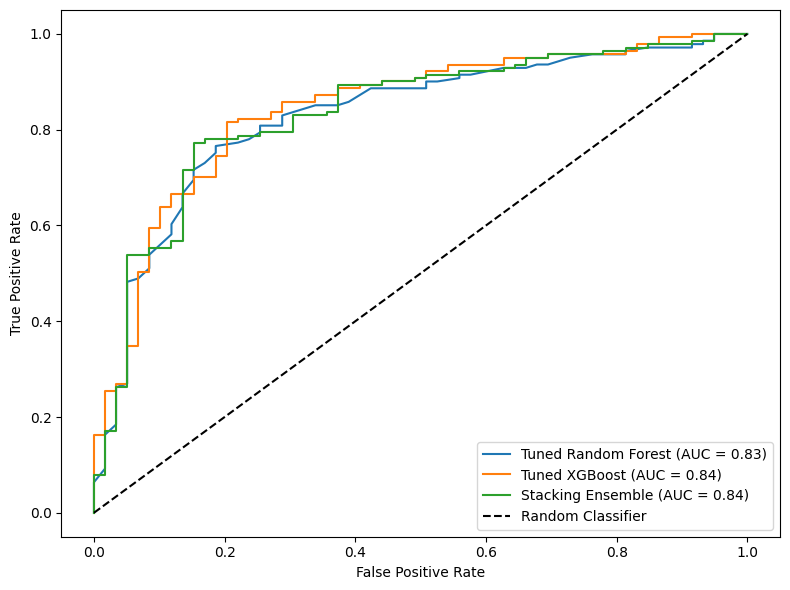

In [177]:
# Plot ROC curves for all 3 models
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    (y_prob_rf, 'Tuned Random Forest'),
    (y_prob_xgb, 'Tuned XGBoost'),
    (y_prob_stack, 'Stacking Ensemble')
]

for y_score, name in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [178]:
# Print classification reports for all 3 models
print('=== Tuned Random Forest ===')
print(classification_report(y_test, y_pred_rf))

print('=== Tuned XGBoost ===')
print(classification_report(y_test, y_pred_xgb))

print('=== Stacking Ensemble ===')
print(classification_report(y_test, y_pred_stack))

=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.65      0.66      0.66        59
           1       0.86      0.85      0.85       141

    accuracy                           0.80       200
   macro avg       0.75      0.76      0.75       200
weighted avg       0.80      0.80      0.80       200

=== Tuned XGBoost ===
              precision    recall  f1-score   support

           0       0.69      0.63      0.65        59
           1       0.85      0.88      0.86       141

    accuracy                           0.81       200
   macro avg       0.77      0.75      0.76       200
weighted avg       0.80      0.81      0.80       200

=== Stacking Ensemble ===
              precision    recall  f1-score   support

           0       0.64      0.63      0.63        59
           1       0.85      0.85      0.85       141

    accuracy                           0.79       200
   macro avg       0.74      0.74      0.74       20

# **LIME explanation for Random Forest Tuned Model**

In [179]:
# Get feature names if you dropped 'credit_risk'
feature_names = df_reduced.drop('credit_risk', axis=1).columns.tolist()

explainer = LimeTabularExplainer(
    training_data=X_train_sm,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification',
    discretize_continuous=True
)

In [180]:
#Choose an instance to explain
i = 4  # for example
instance = X_train_sm[i]

In [181]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

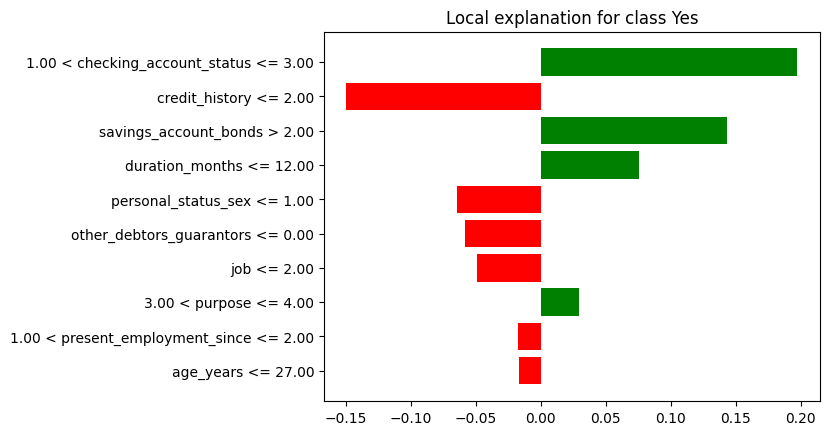

In [182]:
explanation.as_pyplot_figure()

In [183]:
#Choose an instance to explain
i = 6  # for example
instance = X_train_sm[i]

In [184]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

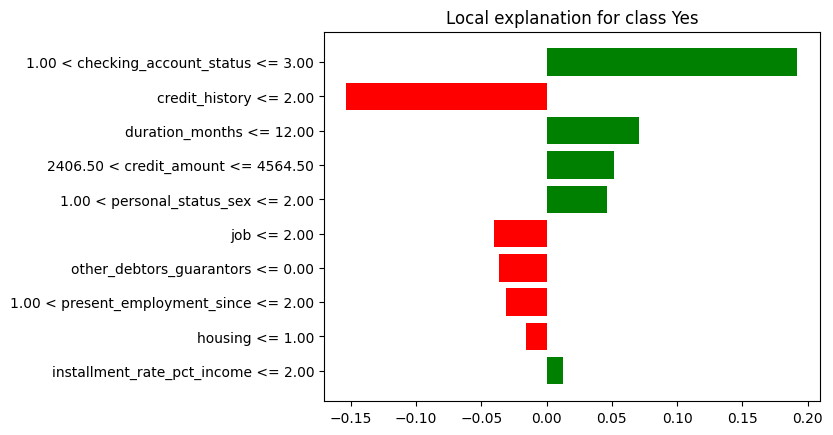

In [185]:
explanation.as_pyplot_figure()

# SHAP Analysis

In [186]:
# SHAP Explainer Initialisation
explainer_shap = shap.TreeExplainer(final_model)
shap_values = explainer_shap.shap_values(X_train_sm)
base_val = explainer_shap.expected_value[1] if isinstance(explainer_shap.expected_value, (list, np.ndarray)) else explainer_shap.expected_value

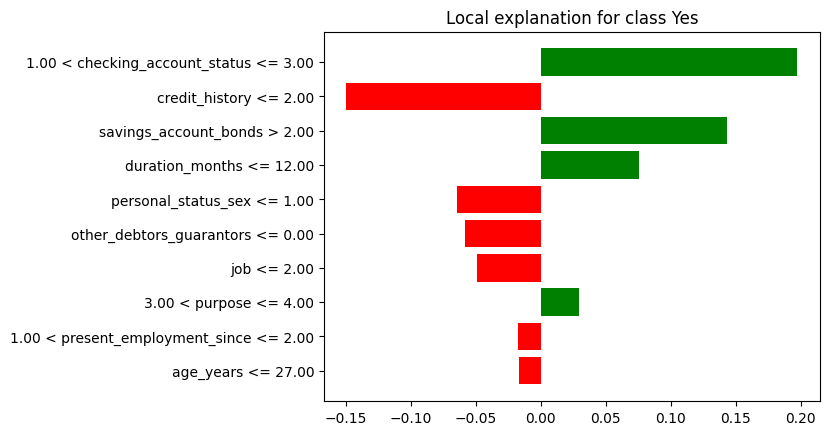

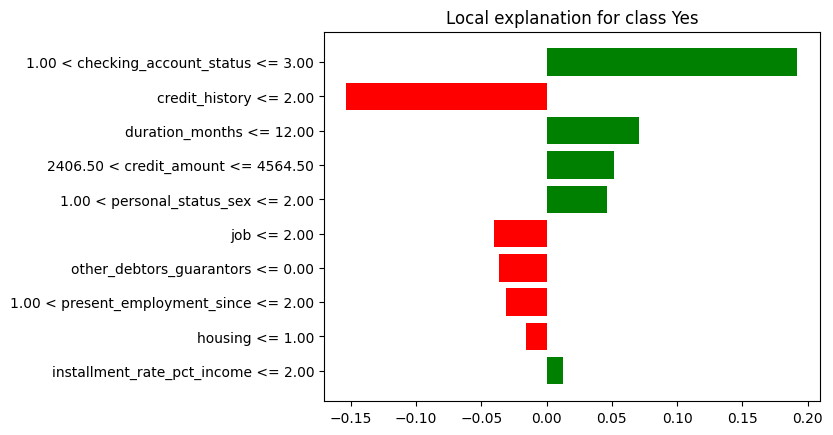

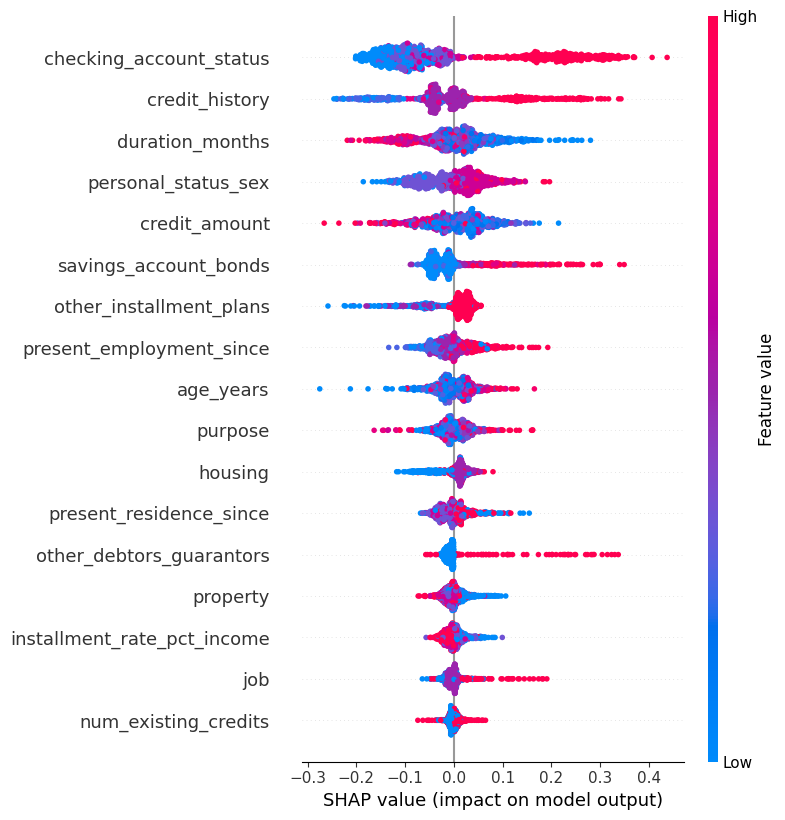

In [187]:
# SHAP Summary Plot
plt.figure()
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1],
    X_train_sm,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.show()

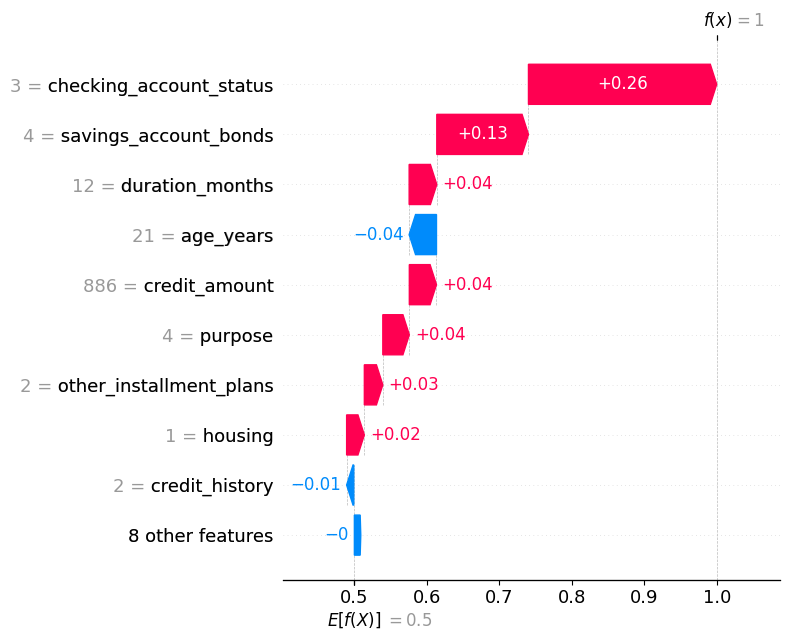

In [188]:
# Instance 4 — SHAP waterfall plot
sv_4 = shap_values[1][4] if isinstance(shap_values, list) else shap_values[4, :, 1]

shap_explanation_4 = shap.Explanation(
    values=sv_4,
    base_values=base_val,
    data=X_train_sm[4],
    feature_names=feature_names
)

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_explanation_4, show=False)
plt.tight_layout()
plt.show()

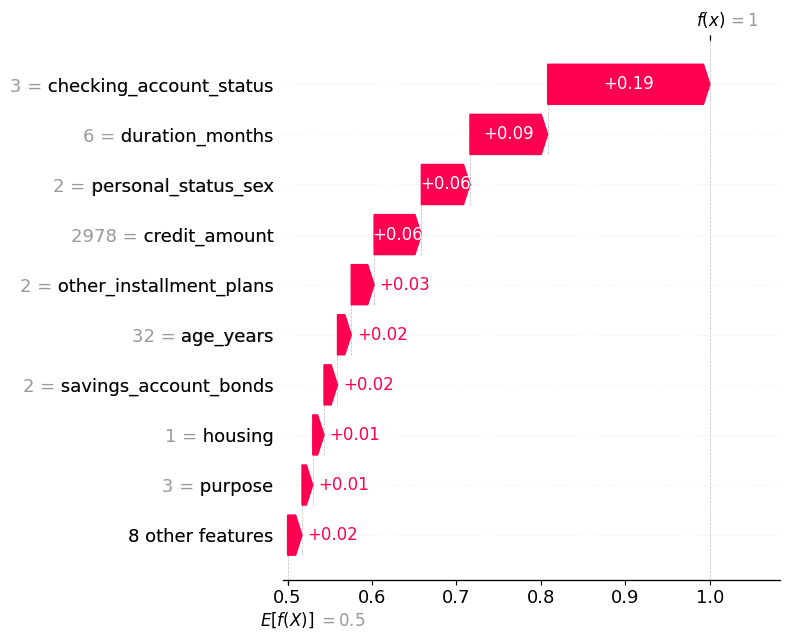

In [189]:
# Instance 6 — SHAP waterfall plot
sv_6 = shap_values[1][6] if isinstance(shap_values, list) else shap_values[6, :, 1]

shap_explanation_6 = shap.Explanation(
    values=sv_6,
    base_values=base_val,
    data=X_train_sm[6],
    feature_names=feature_names
)

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_explanation_6, show=False)
plt.tight_layout()
plt.show()

# SHAP vs LIME Comparison

Instance 4

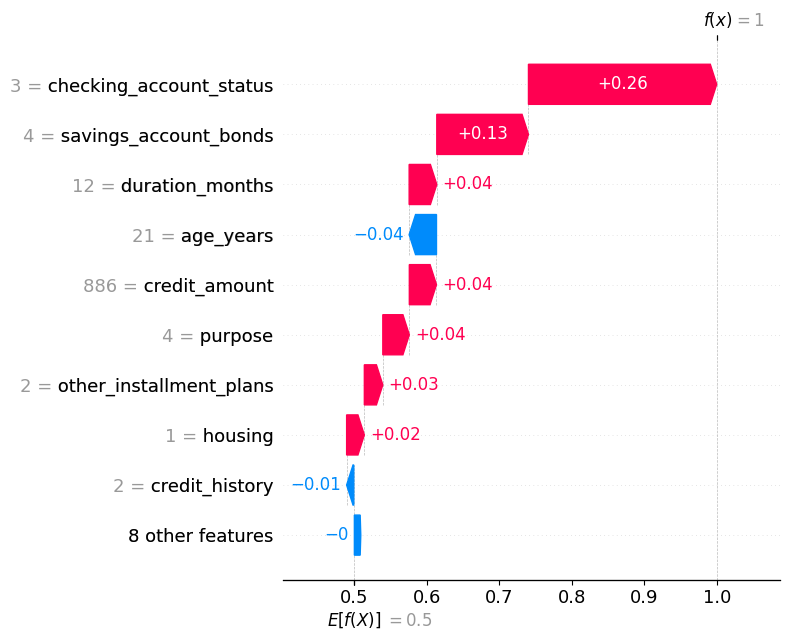

In [190]:
# Instance 4 — SHAP waterfall plot
shap_explanation_4 = shap.Explanation(
    values=sv_4,
    base_values=base_val,
    data=X_train_sm[4],
    feature_names=feature_names
)

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_explanation_4, show=False)
plt.tight_layout()
plt.show()

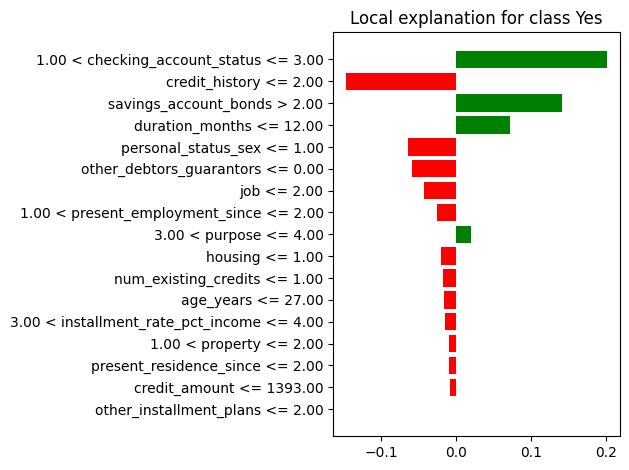

In [191]:
# Instance 4 — LIME explanation
explanation_4 = explainer.explain_instance(
    data_row=X_train_sm[4],
    predict_fn=final_model.predict_proba,
    num_features=len(feature_names)
)
explanation_4.as_pyplot_figure()
plt.tight_layout()
plt.show()

## SHAP vs LIME Analysis

Instance 6

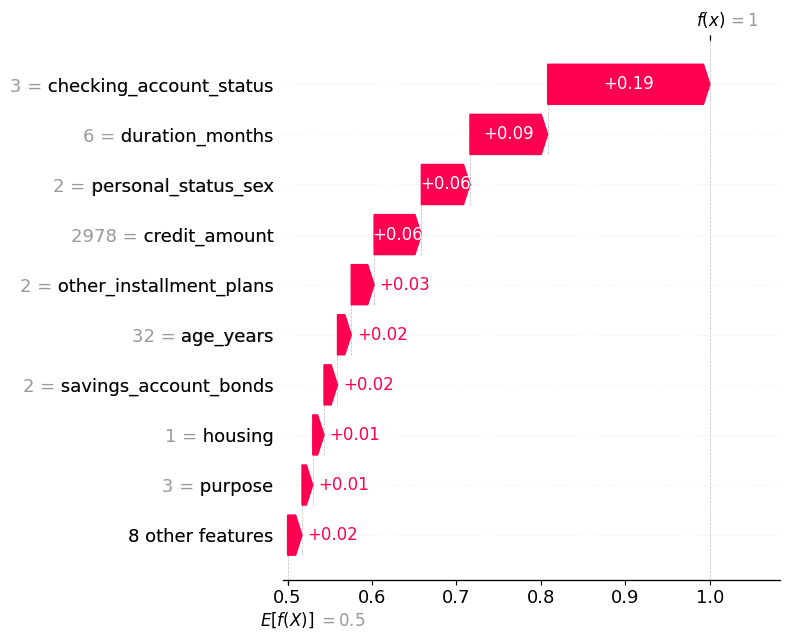

In [192]:
# Instance 6 — SHAP force plot
shap_explanation_6 = shap.Explanation(
    values=sv_6,
    base_values=base_val,
    data=X_train_sm[6],
    feature_names=feature_names
)

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_explanation_6, show=False)
plt.tight_layout()
plt.show()

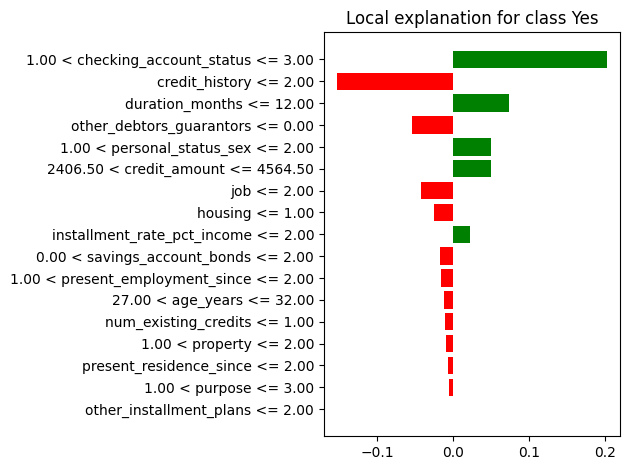

In [193]:
# Instance 6 — LIME explanation
explanation_6 = explainer.explain_instance(
    data_row=X_train_sm[6],
    predict_fn=final_model.predict_proba,
    num_features=len(feature_names)
)
explanation_6.as_pyplot_figure()
plt.tight_layout()
plt.show()